In [1]:
import requests
import pandas as pd

url = "https://getwherenext.com/api/data/cost-of-living/csv"
response = requests.get(url)

with open("cost_of_living.csv", "wb") as f:
    f.write(response.content)

df = pd.read_csv("cost_of_living.csv")
print("Shape:", df.shape)
df.head()

Shape: (95, 10)


,rank,country_code,country,region,cost_index,monthly_estimate_usd,grocery_index,rent_index,utilities_index,transport_index
0,1,EG,Egypt,Africa,19,700,68.0,93.00,93.00,75.0
1,2,IN,India,Asia,21,750,71.0,90.00,90.00,69.0
2,3,LK,Sri Lanka,Asia,21,750,62.0,93.00,93.00,67.0
3,4,MM,Myanmar,Asia,21,750,71.6,81.78,68.28,62.8
4,5,NP,Nepal,Asia,22,800,67.0,90.00,90.00,57.0


In [2]:
# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

print("\nBasic statistics:")
print(df.describe())

print("\nRegions in the data:")
print(df['region'].unique())

Missing values per column:
rank                    0
country_code            0
country                 0
region                  0
cost_index              0
monthly_estimate_usd    0
grocery_index           0
rent_index              0
utilities_index         0
transport_index         0
dtype: int64

Basic statistics:
            rank  cost_index  monthly_estimate_usd  grocery_index  rent_index  \
count  95.000000   95.000000             95.000000      95.000000   95.000000   
mean   48.000000   48.484211           1774.210526      44.676842   65.379895   
std    27.568098   21.839776            802.882545      15.211309   23.747208   
min     1.000000   19.000000            700.000000       0.000000    3.000000   
25%    24.500000   32.000000           1150.000000      36.000000   53.500000   
50%    48.000000   42.000000           1550.000000      45.500000   73.000000   
75%    71.500000   60.500000           2225.000000      55.500000   83.000000   
max    95.000000  109.000000     

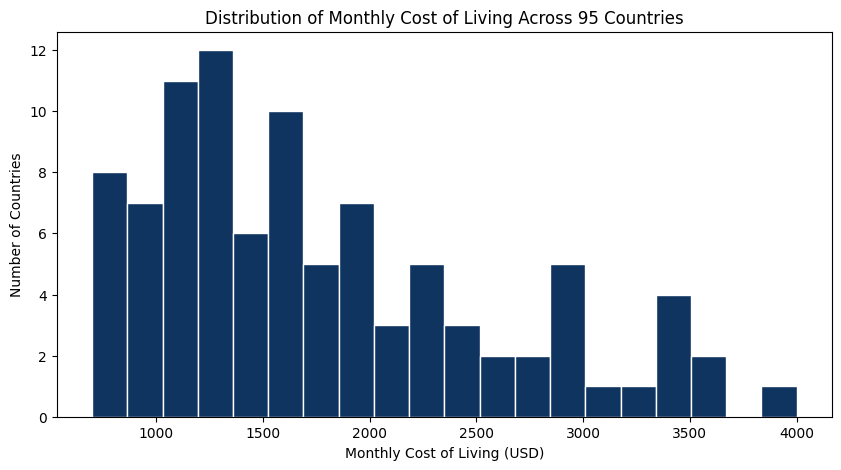

In [3]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(df['monthly_estimate_usd'], bins=20, color='#0f3460', edgecolor='white')
plt.xlabel('Monthly Cost of Living (USD)')
plt.ylabel('Number of Countries')
plt.title('Distribution of Monthly Cost of Living Across 95 Countries')
plt.show()

region
Other           850.000000
Africa         1116.666667
Asia           1336.842105
Americas       1634.375000
Middle East    1975.000000
Europe         2159.459459
Oceania        2387.500000
Name: monthly_estimate_usd, dtype: float64


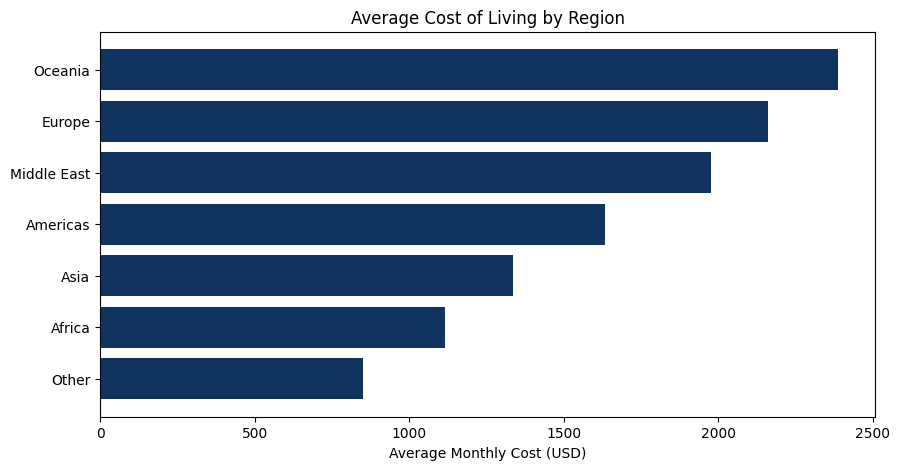

In [4]:
region_avg = df.groupby('region')['monthly_estimate_usd'].mean().sort_values()
print(region_avg)

plt.figure(figsize=(10, 5))
plt.barh(region_avg.index, region_avg.values, color='#0f3460')
plt.xlabel('Average Monthly Cost (USD)')
plt.title('Average Cost of Living by Region')
plt.show()

In [5]:
def compare_countries(country_list):
    comparison = df[df['country'].isin(country_list)]
    return comparison[['country', 'region', 'monthly_estimate_usd',
                        'grocery_index', 'rent_index', 'utilities_index', 'transport_index']]

# Test it with a few countries
result = compare_countries(['Sri Lanka', 'United Kingdom', 'Australia'])
print(result)

           country   region  monthly_estimate_usd  grocery_index  rent_index  \
2        Sri Lanka     Asia                   750           62.0        93.0   
82  United Kingdom   Europe                  2900           45.0        20.0   
88       Australia  Oceania                  3350           26.0        14.0   

    utilities_index  transport_index  
2              93.0             67.0  
82             20.0             20.0  
88             14.0             32.0  


In [6]:
def get_ranking(region_filter=None, top_n=10):
    data = df.copy()
    if region_filter and region_filter != "All":
        data = data[data['region'] == region_filter]
    return data.sort_values('monthly_estimate_usd')[['rank', 'country', 'region', 'monthly_estimate_usd']].head(top_n)

# Test: cheapest 10 countries overall
print("Cheapest 10 overall:")
print(get_ranking(top_n=10))

# Test: cheapest 5 in Europe specifically
print("\nCheapest 5 in Europe:")
print(get_ranking(region_filter="Europe", top_n=5))

Cheapest 10 overall:
   rank    country  region  monthly_estimate_usd
0     1      Egypt  Africa                   700
1     2      India    Asia                   750
2     3  Sri Lanka    Asia                   750
3     4    Myanmar    Asia                   750
4     5      Nepal    Asia                   800
5     6     Rwanda  Africa                   800
6     7     Turkey   Other                   850
7     8    Georgia   Other                   850
8     9    Vietnam    Asia                   900
9    10       Laos    Asia                   900

Cheapest 5 in Europe:
    rank                 country  region  monthly_estimate_usd
10    11                 Moldova  Europe                   950
20    21                 Romania  Europe                  1150
24    25                Bulgaria  Europe                  1150
25    26  Bosnia and Herzegovina  Europe                  1150
26    27                  Serbia  Europe                  1200


In [7]:
df.to_csv("cost_of_living_clean.csv", index=False)

from google.colab import files
files.download("cost_of_living_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
import plotly.express as px

fig = px.bar(
    region_avg.reset_index(),
    x='monthly_estimate_usd',
    y='region',
    orientation='h',
    title='Average Cost of Living by Region',
    labels={'monthly_estimate_usd': 'Average Monthly Cost (USD)', 'region': 'Region'}
)
fig.show()

In [9]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(page_title="Cost of Living Explorer", page_icon="🌍", layout="wide")

@st.cache_data
def load_data():
    return pd.read_csv("cost_of_living_clean.csv")

df = load_data()

st.title("🌍 Cost of Living Explorer")
st.write(
    "Compare the cost of living across 95 countries. Data sourced from the World Bank "
    "International Comparison Program (ICP) 2021, via WhereNext (CC BY 4.0)."
)

st.markdown("---")

# --- Sidebar controls ---
st.sidebar.header("Explore Options")
view_mode = st.sidebar.radio("Choose a view", ["Single Country", "Compare Countries", "Rankings"])

# --- SINGLE COUNTRY VIEW ---
if view_mode == "Single Country":
    country = st.selectbox("Select a country", sorted(df['country'].unique()))
    row = df[df['country'] == country].iloc[0]

    col1, col2, col3 = st.columns(3)
    col1.metric("Monthly Cost", f"${row['monthly_estimate_usd']:,.0f}")
    col2.metric("Cost Rank", f"#{int(row['rank'])} of 95")
    col3.metric("Region", row['region'])

    st.subheader(f"Affordability breakdown for {country}")
    st.caption("Higher score = more affordable, relative to other countries (0-100 scale)")

    breakdown = pd.DataFrame({
        "Category": ["Groceries", "Rent", "Utilities", "Transport"],
        "Affordability Score": [
            row['grocery_index'], row['rent_index'],
            row['utilities_index'], row['transport_index']
        ]
    })
    fig = px.bar(breakdown, x="Category", y="Affordability Score", color="Category",
                 range_y=[0, 100], title=f"{country} — Affordability by Category")
    st.plotly_chart(fig, use_container_width=True)

# --- COMPARE COUNTRIES VIEW ---
elif view_mode == "Compare Countries":
    countries = st.multiselect(
        "Select countries to compare (2-5 recommended)",
        sorted(df['country'].unique()),
        default=["Sri Lanka", "United Kingdom", "Australia"]
    )

    if countries:
        comparison = df[df['country'].isin(countries)]

        fig1 = px.bar(comparison, x="country", y="monthly_estimate_usd", color="country",
                      title="Monthly Cost of Living Comparison",
                      labels={"monthly_estimate_usd": "Monthly Cost (USD)", "country": "Country"})
        st.plotly_chart(fig1, use_container_width=True)

        melted = comparison.melt(
            id_vars=["country"],
            value_vars=["grocery_index", "rent_index", "utilities_index", "transport_index"],
            var_name="Category", value_name="Affordability Score"
        )
        melted["Category"] = melted["Category"].str.replace("_index", "").str.title()

        fig2 = px.bar(melted, x="Category", y="Affordability Score", color="country",
                      barmode="group", range_y=[0, 100],
                      title="Affordability Breakdown by Category")
        st.plotly_chart(fig2, use_container_width=True)

        st.dataframe(comparison[['country', 'region', 'monthly_estimate_usd',
                                   'grocery_index', 'rent_index', 'utilities_index', 'transport_index']],
                     use_container_width=True, hide_index=True)
    else:
        st.info("Select at least one country above to see the comparison.")

# --- RANKINGS VIEW ---
else:
    region_options = ["All"] + sorted(df['region'].unique().tolist())
    region_filter = st.selectbox("Filter by region", region_options)
    top_n = st.slider("Number of countries to show", 5, 30, 10)
    sort_order = st.radio("Sort order", ["Cheapest first", "Most expensive first"])

    data = df.copy()
    if region_filter != "All":
        data = data[data['region'] == region_filter]

    ascending = sort_order == "Cheapest first"
    data = data.sort_values('monthly_estimate_usd', ascending=ascending).head(top_n)

    fig = px.bar(data, x="monthly_estimate_usd", y="country", orientation="h",
                 title=f"{'Cheapest' if ascending else 'Most Expensive'} {top_n} Countries"
                       f"{' in ' + region_filter if region_filter != 'All' else ''}",
                 labels={"monthly_estimate_usd": "Monthly Cost (USD)", "country": "Country"})
    fig.update_layout(yaxis={'categoryorder': 'total ascending' if ascending else 'total descending'})
    st.plotly_chart(fig, use_container_width=True)

st.markdown("---")
st.caption(
    "Data: WhereNext Cost of Living Index 2026, derived from World Bank ICP 2021 Price Level "
    "Indices. Licensed CC BY 4.0. Figures are country-level averages calibrated to a single-person "
    "household and may not reflect city-specific or individual circumstances."
)

Writing app.py


In [10]:
!pip install streamlit -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 102.8 MB/s eta 0:00:00


In [11]:
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) y

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧your url is: https://cute-signs-say.loca.lt
^C


In [12]:
import requests

response = requests.get("https://api.frankfurter.dev/v2/latest?base=USD&symbols=LKR")
data = response.json()
print(data)

{'status': 404, 'message': 'not found'}


In [13]:
import requests

response = requests.get("https://open.er-api.com/v6/latest/USD")
data = response.json()
print("Status:", data['result'])
print("LKR rate:", data['rates']['LKR'])
print("Last updated:", data['time_last_update_utc'])

Status: success
LKR rate: 333.198729
Last updated: Sun, 16 Aug 2026 00:02:31 +0000


In [14]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import requests

st.set_page_config(page_title="Cost of Living Explorer", page_icon="🌍", layout="wide")

@st.cache_data
def load_data():
    return pd.read_csv("cost_of_living_clean.csv")

@st.cache_data(ttl=3600)  # refresh rates once per hour
def get_exchange_rates():
    try:
        response = requests.get("https://open.er-api.com/v6/latest/USD", timeout=5)
        data = response.json()
        if data['result'] == 'success':
            return data['rates'], data['time_last_update_utc']
    except Exception:
        pass
    return None, None

df = load_data()
rates, last_updated = get_exchange_rates()

st.title("🌍 Cost of Living Explorer")
st.write(
    "Compare the cost of living across 95 countries. Data sourced from the World Bank "
    "International Comparison Program (ICP) 2021, via WhereNext (CC BY 4.0)."
)

st.markdown("---")

# --- Sidebar controls ---
st.sidebar.header("Explore Options")

# Currency selector
currency_options = ["USD"] + sorted(rates.keys()) if rates else ["USD"]
selected_currency = st.sidebar.selectbox(
    "Display currency",
    currency_options,
    index=currency_options.index("LKR") if "LKR" in currency_options else 0
)

if rates and selected_currency != "USD":
    conversion_rate = rates[selected_currency]
    st.sidebar.caption(f"1 USD = {conversion_rate:,.2f} {selected_currency}")
    st.sidebar.caption(f"Rates updated: {last_updated}")
else:
    conversion_rate = 1

def convert(usd_amount):
    return usd_amount * conversion_rate

def format_currency(usd_amount):
    converted = convert(usd_amount)
    if selected_currency == "USD":
        return f"${converted:,.0f}"
    else:
        return f"{converted:,.0f} {selected_currency}"

view_mode = st.sidebar.radio("Choose a view", ["Single Country", "Compare Countries", "Rankings"])

# --- SINGLE COUNTRY VIEW ---
if view_mode == "Single Country":
    country = st.selectbox("Select a country", sorted(df['country'].unique()))
    row = df[df['country'] == country].iloc[0]

    col1, col2, col3 = st.columns(3)
    col1.metric("Monthly Cost", format_currency(row['monthly_estimate_usd']))
    col2.metric("Cost Rank", f"#{int(row['rank'])} of 95")
    col3.metric("Region", row['region'])

    st.subheader(f"Affordability breakdown for {country}")
    st.caption("Higher score = more affordable, relative to other countries (0-100 scale)")

    breakdown = pd.DataFrame({
        "Category": ["Groceries", "Rent", "Utilities", "Transport"],
        "Affordability Score": [
            row['grocery_index'], row['rent_index'],
            row['utilities_index'], row['transport_index']
        ]
    })
    fig = px.bar(breakdown, x="Category", y="Affordability Score", color="Category",
                 range_y=[0, 100], title=f"{country} — Affordability by Category")
    st.plotly_chart(fig, use_container_width=True)

# --- COMPARE COUNTRIES VIEW ---
elif view_mode == "Compare Countries":
    countries = st.multiselect(
        "Select countries to compare (2-5 recommended)",
        sorted(df['country'].unique()),
        default=["Sri Lanka", "United Kingdom", "Australia"]
    )

    if countries:
        comparison = df[df['country'].isin(countries)].copy()
        comparison['display_cost'] = comparison['monthly_estimate_usd'].apply(convert)

        fig1 = px.bar(comparison, x="country", y="display_cost", color="country",
                      title=f"Monthly Cost of Living Comparison ({selected_currency})",
                      labels={"display_cost": f"Monthly Cost ({selected_currency})", "country": "Country"})
        st.plotly_chart(fig1, use_container_width=True)

        melted = comparison.melt(
            id_vars=["country"],
            value_vars=["grocery_index", "rent_index", "utilities_index", "transport_index"],
            var_name="Category", value_name="Affordability Score"
        )
        melted["Category"] = melted["Category"].str.replace("_index", "").str.title()

        fig2 = px.bar(melted, x="Category", y="Affordability Score", color="country",
                      barmode="group", range_y=[0, 100],
                      title="Affordability Breakdown by Category")
        st.plotly_chart(fig2, use_container_width=True)

        display_table = comparison[['country', 'region', 'display_cost',
                                      'grocery_index', 'rent_index', 'utilities_index', 'transport_index']].copy()
        display_table = display_table.rename(columns={'display_cost': f'Monthly Cost ({selected_currency})'})
        st.dataframe(display_table, use_container_width=True, hide_index=True)
    else:
        st.info("Select at least one country above to see the comparison.")

# --- RANKINGS VIEW ---
else:
    region_options = ["All"] + sorted(df['region'].unique().tolist())
    region_filter = st.selectbox("Filter by region", region_options)
    top_n = st.slider("Number of countries to show", 5, 30, 10)
    sort_order = st.radio("Sort order", ["Cheapest first", "Most expensive first"])

    data = df.copy()
    if region_filter != "All":
        data = data[data['region'] == region_filter]

    ascending = sort_order == "Cheapest first"
    data = data.sort_values('monthly_estimate_usd', ascending=ascending).head(top_n)
    data['display_cost'] = data['monthly_estimate_usd'].apply(convert)

    fig = px.bar(data, x="display_cost", y="country", orientation="h",
                 title=f"{'Cheapest' if ascending else 'Most Expensive'} {top_n} Countries"
                       f"{' in ' + region_filter if region_filter != 'All' else ''} ({selected_currency})",
                 labels={"display_cost": f"Monthly Cost ({selected_currency})", "country": "Country"})
    fig.update_layout(yaxis={'categoryorder': 'total ascending' if ascending else 'total descending'})
    st.plotly_chart(fig, use_container_width=True)

st.markdown("---")
st.caption(
    "Data: WhereNext Cost of Living Index 2026, derived from World Bank ICP 2021 Price Level "
    "Indices. Licensed CC BY 4.0. Exchange rates via the ExchangeRate-API open access endpoint "
    "(exchangerate-api.com). Figures are country-level averages calibrated to a single-person "
    "household and may not reflect city-specific or individual circumstances."
)

Overwriting app.py


In [15]:
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹your url is: https://four-chefs-play.loca.lt
^C


In [16]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import requests

st.set_page_config(page_title="Cost of Living Explorer", page_icon="🌍", layout="wide")

@st.cache_data
def load_data():
    return pd.read_csv("cost_of_living_clean.csv")

@st.cache_data(ttl=3600)
def get_exchange_rates():
    try:
        response = requests.get("https://open.er-api.com/v6/latest/USD", timeout=5)
        data = response.json()
        if data['result'] == 'success':
            return data['rates'], data['time_last_update_utc']
    except Exception:
        pass
    return None, None

df = load_data()
rates, last_updated = get_exchange_rates()

st.title("🌍 Cost of Living Explorer")
st.write(
    "Compare the cost of living across 95 countries. Data sourced from the World Bank "
    "International Comparison Program (ICP) 2021, via WhereNext (CC BY 4.0)."
)
st.markdown("---")

# --- Sidebar controls ---
st.sidebar.header("Explore Options")

currency_options = ["USD"] + sorted(rates.keys()) if rates else ["USD"]
selected_currency = st.sidebar.selectbox(
    "Display currency", currency_options,
    index=currency_options.index("LKR") if "LKR" in currency_options else 0
)

if rates and selected_currency != "USD":
    conversion_rate = rates[selected_currency]
    st.sidebar.caption(f"1 USD = {conversion_rate:,.2f} {selected_currency}")
    st.sidebar.caption(f"Rates updated: {last_updated}")
else:
    conversion_rate = 1

def convert(usd_amount):
    return usd_amount * conversion_rate

def format_currency(usd_amount):
    converted = convert(usd_amount)
    return f"${converted:,.0f}" if selected_currency == "USD" else f"{converted:,.0f} {selected_currency}"

view_mode = st.sidebar.radio(
    "Choose a view",
    ["Single Country", "Compare Countries", "Rankings", "World Map", "Budget Finder"]
)

# --- SINGLE COUNTRY VIEW ---
if view_mode == "Single Country":
    country = st.selectbox("Select a country", sorted(df['country'].unique()))
    row = df[df['country'] == country].iloc[0]

    col1, col2, col3 = st.columns(3)
    col1.metric("Monthly Cost", format_currency(row['monthly_estimate_usd']))
    col2.metric("Cost Rank", f"#{int(row['rank'])} of 95")
    col3.metric("Region", row['region'])

    st.subheader(f"Affordability breakdown for {country}")
    st.caption("Higher score = more affordable, relative to other countries (0-100 scale)")

    breakdown = pd.DataFrame({
        "Category": ["Groceries", "Rent", "Utilities", "Transport"],
        "Affordability Score": [row['grocery_index'], row['rent_index'],
                                  row['utilities_index'], row['transport_index']]
    })
    fig = px.bar(breakdown, x="Category", y="Affordability Score", color="Category",
                 range_y=[0, 100], title=f"{country} — Affordability by Category")
    st.plotly_chart(fig, use_container_width=True)

# --- COMPARE COUNTRIES VIEW ---
elif view_mode == "Compare Countries":
    countries = st.multiselect(
        "Select countries to compare (2-5 recommended)",
        sorted(df['country'].unique()),
        default=["Sri Lanka", "United Kingdom", "Australia"]
    )
    if countries:
        comparison = df[df['country'].isin(countries)].copy()
        comparison['display_cost'] = comparison['monthly_estimate_usd'].apply(convert)

        fig1 = px.bar(comparison, x="country", y="display_cost", color="country",
                      title=f"Monthly Cost of Living Comparison ({selected_currency})",
                      labels={"display_cost": f"Monthly Cost ({selected_currency})", "country": "Country"})
        st.plotly_chart(fig1, use_container_width=True)

        melted = comparison.melt(
            id_vars=["country"],
            value_vars=["grocery_index", "rent_index", "utilities_index", "transport_index"],
            var_name="Category", value_name="Affordability Score"
        )
        melted["Category"] = melted["Category"].str.replace("_index", "").str.title()

        fig2 = px.bar(melted, x="Category", y="Affordability Score", color="country",
                      barmode="group", range_y=[0, 100], title="Affordability Breakdown by Category")
        st.plotly_chart(fig2, use_container_width=True)

        display_table = comparison[['country', 'region', 'display_cost', 'grocery_index',
                                      'rent_index', 'utilities_index', 'transport_index']].copy()
        display_table = display_table.rename(columns={'display_cost': f'Monthly Cost ({selected_currency})'})
        st.dataframe(display_table, use_container_width=True, hide_index=True)
    else:
        st.info("Select at least one country above to see the comparison.")

# --- RANKINGS VIEW ---
elif view_mode == "Rankings":
    region_options = ["All"] + sorted(df['region'].unique().tolist())
    region_filter = st.selectbox("Filter by region", region_options)
    top_n = st.slider("Number of countries to show", 5, 30, 10)
    sort_order = st.radio("Sort order", ["Cheapest first", "Most expensive first"])

    data = df.copy()
    if region_filter != "All":
        data = data[data['region'] == region_filter]

    ascending = sort_order == "Cheapest first"
    data = data.sort_values('monthly_estimate_usd', ascending=ascending).head(top_n)
    data['display_cost'] = data['monthly_estimate_usd'].apply(convert)

    fig = px.bar(data, x="display_cost", y="country", orientation="h",
                 title=f"{'Cheapest' if ascending else 'Most Expensive'} {top_n} Countries"
                       f"{' in ' + region_filter if region_filter != 'All' else ''} ({selected_currency})",
                 labels={"display_cost": f"Monthly Cost ({selected_currency})", "country": "Country"})
    fig.update_layout(yaxis={'categoryorder': 'total ascending' if ascending else 'total descending'})
    st.plotly_chart(fig, use_container_width=True)

# --- WORLD MAP VIEW ---
elif view_mode == "World Map":
    st.subheader("Cost of Living Around the World")
    st.caption("Darker = more expensive. Hover over any country for details.")

    map_df = df.copy()
    map_df['display_cost'] = map_df['monthly_estimate_usd'].apply(convert)

    fig = px.choropleth(
        map_df,
        locations="country_code",
        color="cost_index",
        hover_name="country",
        hover_data={"display_cost": ":,.0f", "country_code": False, "cost_index": True},
        color_continuous_scale="YlOrRd",
        title="Cost of Living Index by Country",
        labels={"cost_index": "Cost Index"}
    )
    fig.update_layout(height=550, margin={"r": 0, "t": 40, "l": 0, "b": 0})
    st.plotly_chart(fig, use_container_width=True)

# --- BUDGET FINDER VIEW ---
else:
    st.subheader("Find Countries Within Your Budget")

    default_budget = int(convert(1500))
    budget = st.number_input(
        f"Your monthly budget ({selected_currency})",
        min_value=0, value=default_budget, step=int(convert(50)) or 1
    )

    budget_in_usd = budget / conversion_rate
    affordable = df[df['monthly_estimate_usd'] <= budget_in_usd].copy()
    affordable['display_cost'] = affordable['monthly_estimate_usd'].apply(convert)
    affordable = affordable.sort_values('monthly_estimate_usd')

    st.write(f"**{len(affordable)} of 95 countries** fit within a budget of "
             f"{budget:,.0f} {selected_currency}/month.")

    if len(affordable) > 0:
        fig = px.bar(affordable, x="display_cost", y="country", orientation="h",
                     color="region", title="Countries Within Your Budget",
                     labels={"display_cost": f"Monthly Cost ({selected_currency})", "country": "Country"},
                     height=max(400, len(affordable) * 20))
        fig.update_layout(yaxis={'categoryorder': 'total ascending'})
        st.plotly_chart(fig, use_container_width=True)
    else:
        st.warning("No countries fit within this budget. Try increasing it.")

st.markdown("---")
st.caption(
    "Data: WhereNext Cost of Living Index 2026, derived from World Bank ICP 2021 Price Level "
    "Indices. Licensed CC BY 4.0. Exchange rates via the ExchangeRate-API open access endpoint "
    "(exchangerate-api.com). Figures are country-level averages calibrated to a single-person "
    "household and may not reflect city-specific or individual circumstances."
)

Overwriting app.py


In [17]:
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://clever-bags-fry.loca.lt
^C


In [18]:
import plotly.express as px

fig = px.choropleth(
    df,
    locations="country",
    locationmode="country names",
    color="cost_index",
    hover_name="country",
    color_continuous_scale="YlOrRd",
    title="Cost of Living Index by Country"
)
fig.update_geos(projection_type="orthographic", showcountries=True)
fig.update_layout(height=600)
fig.show()

In [19]:
map_df = df.copy()
map_df['display_cost'] = map_df['monthly_estimate_usd'].apply(convert) if 'convert' in dir() else map_df['monthly_estimate_usd']

fig = px.choropleth(
    map_df,
    locations="country",
    locationmode="country names",
    color="monthly_estimate_usd",
    hover_name="country",
    hover_data={"monthly_estimate_usd": ":,.0f"},
    color_continuous_scale="YlOrRd",
    title="Estimated Monthly Cost of Living (USD)",
    labels={"monthly_estimate_usd": "Monthly Cost (USD)"}
)
fig.update_geos(projection_type="orthographic", showcountries=True)
fig.update_layout(height=600)
fig.show()

In [20]:
elif view_mode == "World Map":
    st.subheader("Cost of Living Around the World")

    with st.expander("ℹ️ What am I looking at?"):
        st.write(
            "This globe shows the **estimated monthly cost of living for one person** "
            "(rent, groceries, utilities, and transport combined) in each country. "
            "**Darker red = more expensive**, **lighter yellow = more affordable**. "
            "Click and drag the globe to rotate it, scroll to zoom, and hover over any "
            "country to see its exact estimated monthly cost."
        )

    map_df = df.copy()
    map_df['display_cost'] = map_df['monthly_estimate_usd'].apply(convert)

    fig = px.choropleth(
        map_df,
        locations="country",
        locationmode="country names",
        color="monthly_estimate_usd",
        hover_name="country",
        hover_data={"display_cost": ":,.0f", "monthly_estimate_usd": False},
        color_continuous_scale="YlOrRd",
        title=f"Estimated Monthly Cost of Living",
        labels={"monthly_estimate_usd": "Cost (USD)", "display_cost": f"Cost ({selected_currency})"}
    )
    fig.update_geos(projection_type="orthographic", showcountries=True)
    fig.update_layout(height=600, margin={"r": 0, "t": 40, "l": 0, "b": 0})
    st.plotly_chart(fig, use_container_width=True)

SyntaxError: invalid syntax (439205504.py, line 1)

In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import requests

st.set_page_config(page_title="Cost of Living Explorer", page_icon="🌍", layout="wide")

@st.cache_data
def load_data():
    return pd.read_csv("cost_of_living_clean.csv")

@st.cache_data(ttl=3600)
def get_exchange_rates():
    try:
        response = requests.get("https://open.er-api.com/v6/latest/USD", timeout=5)
        data = response.json()
        if data['result'] == 'success':
            return data['rates'], data['time_last_update_utc']
    except Exception:
        pass
    return None, None

df = load_data()
rates, last_updated = get_exchange_rates()

st.title("🌍 Cost of Living Explorer")
st.write(
    "Compare the cost of living across 95 countries. Data sourced from the World Bank "
    "International Comparison Program (ICP) 2021, via WhereNext (CC BY 4.0)."
)
st.markdown("---")

st.sidebar.header("Explore Options")

currency_options = ["USD"] + sorted(rates.keys()) if rates else ["USD"]
selected_currency = st.sidebar.selectbox(
    "Display currency", currency_options,
    index=currency_options.index("LKR") if "LKR" in currency_options else 0
)

if rates and selected_currency != "USD":
    conversion_rate = rates[selected_currency]
    st.sidebar.caption(f"1 USD = {conversion_rate:,.2f} {selected_currency}")
    st.sidebar.caption(f"Rates updated: {last_updated}")
else:
    conversion_rate = 1

def convert(usd_amount):
    return usd_amount * conversion_rate

def format_currency(usd_amount):
    converted = convert(usd_amount)
    return f"${converted:,.0f}" if selected_currency == "USD" else f"{converted:,.0f} {selected_currency}"

view_mode = st.sidebar.radio(
    "Choose a view",
    ["Single Country", "Compare Countries", "Rankings", "World Map", "Budget Finder"]
)

# --- SINGLE COUNTRY VIEW ---
if view_mode == "Single Country":
    country = st.selectbox("Select a country", sorted(df['country'].unique()))
    row = df[df['country'] == country].iloc[0]

    col1, col2, col3 = st.columns(3)
    col1.metric("Monthly Cost", format_currency(row['monthly_estimate_usd']))
    col2.metric("Cost Rank", f"#{int(row['rank'])} of 95")
    col3.metric("Region", row['region'])

    st.subheader(f"Affordability breakdown for {country}")
    st.caption("Higher score = more affordable, relative to other countries (0-100 scale)")

    breakdown = pd.DataFrame({
        "Category": ["Groceries", "Rent", "Utilities", "Transport"],
        "Affordability Score": [row['grocery_index'], row['rent_index'],
                                  row['utilities_index'], row['transport_index']]
    })
    fig = px.bar(breakdown, x="Category", y="Affordability Score", color="Category",
                 range_y=[0, 100], title=f"{country} — Affordability by Category")
    st.plotly_chart(fig, use_container_width=True)

# --- COMPARE COUNTRIES VIEW ---
elif view_mode == "Compare Countries":
    countries = st.multiselect(
        "Select countries to compare (2-5 recommended)",
        sorted(df['country'].unique()),
        default=["Sri Lanka", "United Kingdom", "Australia"]
    )
    if countries:
        comparison = df[df['country'].isin(countries)].copy()
        comparison['display_cost'] = comparison['monthly_estimate_usd'].apply(convert)

        fig1 = px.bar(comparison, x="country", y="display_cost", color="country",
                      title=f"Monthly Cost of Living Comparison ({selected_currency})",
                      labels={"display_cost": f"Monthly Cost ({selected_currency})", "country": "Country"})
        st.plotly_chart(fig1, use_container_width=True)

        melted = comparison.melt(
            id_vars=["country"],
            value_vars=["grocery_index", "rent_index", "utilities_index", "transport_index"],
            var_name="Category", value_name="Affordability Score"
        )
        melted["Category"] = melted["Category"].str.replace("_index", "").str.title()

        fig2 = px.bar(melted, x="Category", y="Affordability Score", color="country",
                      barmode="group", range_y=[0, 100], title="Affordability Breakdown by Category")
        st.plotly_chart(fig2, use_container_width=True)

        display_table = comparison[['country', 'region', 'display_cost', 'grocery_index',
                                      'rent_index', 'utilities_index', 'transport_index']].copy()
        display_table = display_table.rename(columns={'display_cost': f'Monthly Cost ({selected_currency})'})
        st.dataframe(display_table, use_container_width=True, hide_index=True)
    else:
        st.info("Select at least one country above to see the comparison.")

# --- RANKINGS VIEW ---
elif view_mode == "Rankings":
    region_options = ["All"] + sorted(df['region'].unique().tolist())
    region_filter = st.selectbox("Filter by region", region_options)
    top_n = st.slider("Number of countries to show", 5, 30, 10)
    sort_order = st.radio("Sort order", ["Cheapest first", "Most expensive first"])

    data = df.copy()
    if region_filter != "All":
        data = data[data['region'] == region_filter]

    ascending = sort_order == "Cheapest first"
    data = data.sort_values('monthly_estimate_usd', ascending=ascending).head(top_n)
    data['display_cost'] = data['monthly_estimate_usd'].apply(convert)

    fig = px.bar(data, x="display_cost", y="country", orientation="h",
                 title=f"{'Cheapest' if ascending else 'Most Expensive'} {top_n} Countries"
                       f"{' in ' + region_filter if region_filter != 'All' else ''} ({selected_currency})",
                 labels={"display_cost": f"Monthly Cost ({selected_currency})", "country": "Country"})
    fig.update_layout(yaxis={'categoryorder': 'total ascending' if ascending else 'total descending'})
    st.plotly_chart(fig, use_container_width=True)

# --- WORLD MAP VIEW ---
elif view_mode == "World Map":
    st.subheader("Cost of Living Around the World")

    with st.expander("ℹ️ What am I looking at?"):
        st.write(
            "This globe shows the **estimated monthly cost of living for one person** "
            "(rent, groceries, utilities, and transport combined) in each country. "
            "**Darker red = more expensive**, **lighter yellow = more affordable**. "
            "Click and drag the globe to rotate it, scroll to zoom, and hover over any "
            "country to see its exact estimated monthly cost."
        )

    map_df = df.copy()
    map_df['display_cost'] = map_df['monthly_estimate_usd'].apply(convert)

    fig = px.choropleth(
        map_df,
        locations="country",
        locationmode="country names",
        color="monthly_estimate_usd",
        hover_name="country",
        hover_data={"display_cost": ":,.0f", "monthly_estimate_usd": False},
        color_continuous_scale="YlOrRd",
        title="Estimated Monthly Cost of Living",
        labels={"monthly_estimate_usd": "Cost (USD)", "display_cost": f"Cost ({selected_currency})"}
    )
    fig.update_geos(projection_type="orthographic", showcountries=True)
    fig.update_layout(height=600, margin={"r": 0, "t": 40, "l": 0, "b": 0})
    st.plotly_chart(fig, use_container_width=True)

# --- BUDGET FINDER VIEW ---
else:
    st.subheader("Find Countries Within Your Budget")

    default_budget = int(convert(1500))
    budget = st.number_input(
        f"Your monthly budget ({selected_currency})",
        min_value=0, value=default_budget, step=int(convert(50)) or 1
    )

    budget_in_usd = budget / conversion_rate
    affordable = df[df['monthly_estimate_usd'] <= budget_in_usd].copy()
    affordable['display_cost'] = affordable['monthly_estimate_usd'].apply(convert)
    affordable = affordable.sort_values('monthly_estimate_usd')

    st.write(f"**{len(affordable)} of 95 countries** fit within a budget of "
             f"{budget:,.0f} {selected_currency}/month.")

    if len(affordable) > 0:
        fig = px.bar(affordable, x="display_cost", y="country", orientation="h",
                     color="region", title="Countries Within Your Budget",
                     labels={"display_cost": f"Monthly Cost ({selected_currency})", "country": "Country"},
                     height=max(400, len(affordable) * 20))
        fig.update_layout(yaxis={'categoryorder': 'total ascending'})
        st.plotly_chart(fig, use_container_width=True)
    else:
        st.warning("No countries fit within this budget. Try increasing it.")

st.markdown("---")
st.caption(
    "Data: WhereNext Cost of Living Index 2026, derived from World Bank ICP 2021 Price Level "
    "Indices. Licensed CC BY 4.0. Exchange rates via the ExchangeRate-API open access endpoint "
    "(exchangerate-api.com). Figures are country-level averages calibrated to a single-person "
    "household and may not reflect city-specific or individual circumstances."
)

Overwriting app.py


In [22]:
!streamlit run app.py &>/content/logs.txt &
!npx localtunnel --port 8501

⠙⠹⠸⠼⠴⠦⠧⠇your url is: https://ninety-numbers-sell.loca.lt
^C


In [23]:
from google.colab import files

files.download("app.py")
files.download("cost_of_living_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>